# GG3209 Spatial Analysis with GIS - Research Report

* **Authors:** Lucy Groves

* **Student ID:** 230012841

* **Date:** 17/09/2026

**Abstract:**

This study applies a GIS-based Multi-Criteria Evaluation to identify areas around Dumfries, Scotland, suitable for new residential development when accounting for projected future flood risk from the River Nith. Suitability was assessed using three continuous criteria — distance to roads, rivers, and existing houses — standardised and equally weighted, alongside three Boolean constraints excluding steep slopes (>10°), future flood extents, and built-up areas. Spatial preparation, weighting and overlay was conducted in QGIS, and statistics using Python. Given the Whitesand’s history of over 200 floods since 1827 (Giancarlo Rinaldi & Luke Jarmyn, 2023) and the Council's recent £68.6 million flood protection scheme (Hakimian, 2025), this analysis found 56.7% of the study area at least moderately suitable, narrowing to 26.5% under a stricter threshold, with suitable land concentrated in a ring surrounding the existing town.


**Keywords:** Multi-Criteria Evaluation, GIS, flood risk, residential suitability, River Nith, climate change adaptation

# GitHub Repository
- **GitHub Link:** https://github.com/LGroves18/GG3209_Research_Report

## Declaration

> In submitting this assignment, I hereby confirm that I have read the University's statement on Good Academic Practice. The following work is my own. Significant academic debts and borrowings have been properly acknowledged and referenced.


**Table of Contents:**

1. Abstract
2. Introduction
3. Methodology
4. Results
5. Discussion
6. Conclusion
7. References


## Introduction

Flooding is among the most significant natural hazards affecting land use planning in Scotland (Audit Scotland, 2025), and climate change is projected to increase both the frequency and extent of river flooding over the coming decades (UK Centre for Ecology & Hydrology, 2025). The River Nith, which flows through Dumfries, presents a recurring flood risk to the town, and any expansion of residential development into the surrounding area must account not only for current flood extents but for how that risk is projected to change under future climate scenarios. Scotland’s National Planning Framework 4 (NPF4) requires planning authorities to consider flood risk in development decisions and to promote avoidance of flood prone land as a first principle (Scottish Government, 2023). This creates a clear practical need for spatial tools that can identify which areas remain suitable for new housing once future flood risk is properly accounted for.

This study addresses the research question: **which areas around Dumfries are most suitable for new residential development when accounting for projected future flood risk from the River Nith?**

Geographic Information System (GIS)-based Multi-Criteria Evaluation (MCE) is a well-established method for answering land suitability questions of this kind, combining multiple spatial datasets into a single suitability score through a weighted overlay process, and has been widely applied across land-use planning contexts ranging from housing allocation to hazard and risk assessment (Chen, Blong and Jacobson, 2001).

This study draws on the Scottish Environment Protection Agency's (SEPA) climate-change-adjusted future river flood extent data for the Nith, combined with transport accessibility, settlement proximity, slope, and river proximity criteria, to produce a suitability model that directly reflects current Scottish planning policy on flood risk avoidance.
Beyond this specific application, GIS-based MCE more broadly offers planners and researchers a way to visualise spatial patterns of risk and suitability, compare alternative sites systematically, and support decisions under multiple, competing, spatial criteria (QGIS, 2018). By combining transparent, reproducible spatial analysis with locally relevant flood risk data, this study aims to demonstrate how such methods can inform more flood-resilient residential planning in a Scottish riverine town context.




## Methodology

The study area comprises a 5km radius buffer centred on Dumfries town centre, selected to encompass the existing urban area, the River Nith corridor, and adjacent land with potential for residential expansion. All spatial data were processed in the British National Grid coordinate reference system (EPSG:27700) at a common resolution of 50m, matching the resolution of the elevation dataset.

Six datasets underpinned the analysis: OS Terrain 50 for elevation, OS Open Roads and OS Open Rivers for the transport and hydrological network, OS Local for existing residential building locations, OS Open Built Up Areas for existing settlement extent, and the Scottish Environment Protection Agency's (SEPA) medium-likelihood future river flood extent for the Nith, adjusted for climate change allowances. The future flood layer was used in preference to the present-day extent because the study's research question is specifically concerned with suitability under projected future conditions, consistent with the flood risk avoidance principle set out in National Planning Framework 4.
Preprocessing was conducted entirely in QGIS. A single point was placed at Dumfries town centre and buffered by 5,000m to define the study area boundary, which was then used to clip all input layers. Because neighbourhood-based raster operations such as slope calculation can produce artificial edge effects when run on a pre-clipped surface, slope was instead calculated from the full merged, unclipped elevation model and clipped afterwards.

Three continuous suitability factors were derived by converting vector layers (roads, the River Nith, and existing houses from OS Local) to raster, computing distance surfaces using the Proximity tool, and standardising each to a common 0–1 scale, following the principle that criteria measured in different units cannot be meaningfully combined without prior standardisation. Distance to roads and distance to existing houses were inverted during standardisation, since proximity to infrastructure and existing residential development was considered desirable, whereas distance to the River Nith was left uninverted, treating greater distance from the watercourse as more suitable, capturing residual flood-adjacent risk not fully expressed by the mapped flood extent alone.

In addition to these graded factors, three constraints were encoded as Boolean rasters (1 = suitable, 0 = excluded): land within the SEPA future flood extent, land within existing built-up areas, and land exceeding a slope threshold of 10° (Montgomery Homes, 2021). The three continuous factors were combined into a single suitability score in QGIS using an equal weighted combination.  



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
pip install contextily

In [3]:
pip install mapclassify

In [4]:
pip install earthpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.7 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio as rio
from rasterio.plot import show
import contextily as ctx

## Figure 1 shows the study area boundary surrounding Dumfries, Scotland.

In [31]:
# Figure 1:

study_area = gpd.read_file(
    "/content/drive/MyDrive/GG3209_Research_Report/study_area.gpkg"
)

study_area.explore(color="red", style_kwds={"fillOpacity": 0}, tiles="CartoDB positron")

## Figure 2 shows the original clipped continous and constraint layers and their corresponding normalised raster layers. Blue represents 0 (unsuitable) and Yellow represents 1 (suitable).

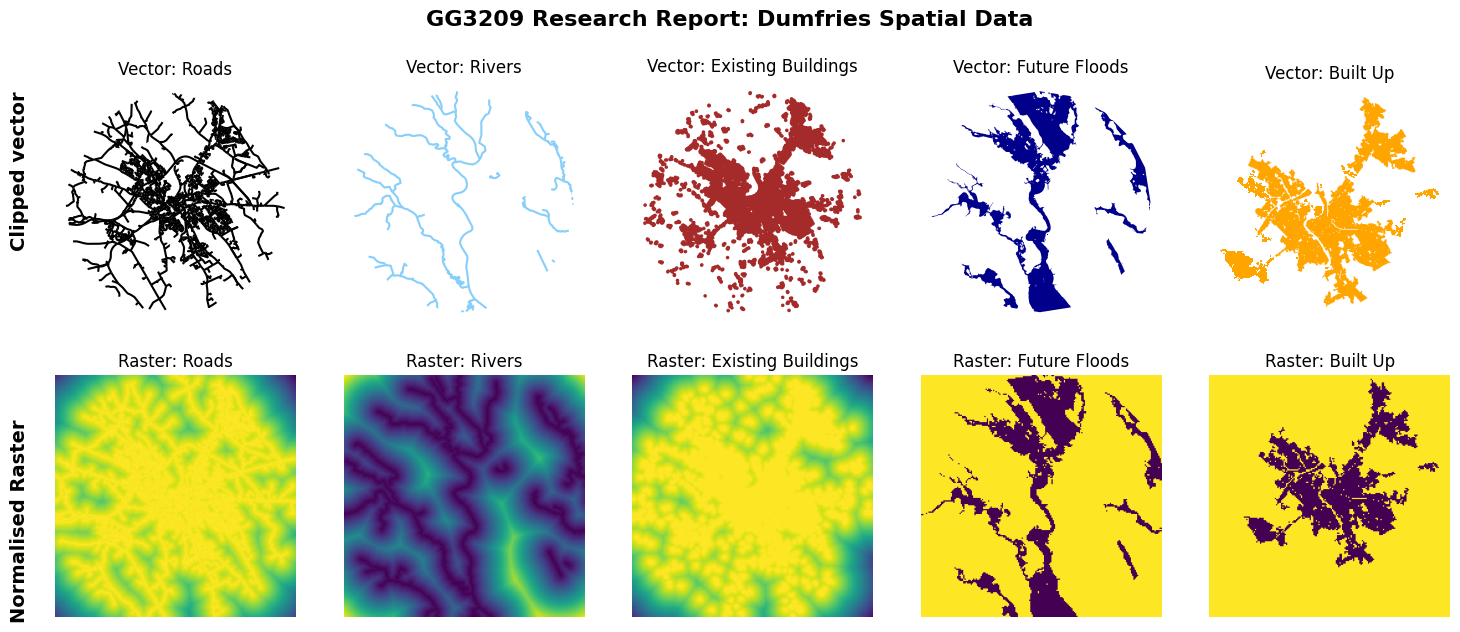

In [23]:
# Figure 2:

folder = "/content/drive/MyDrive/GG3209_Research_Report/"

dataset = [
    ("Roads", "Roads_Clipped.gpkg", "Roads_aligned.tif", "black"),
    ("Rivers", "Rivers_Clipped.gpkg", "Rivers_aligned.tif", "lightskyblue"),
    ("Existing Buildings", "Buffer.gpkg", "Houses_Calc.tif", "brown"),
    ("Future Floods", "FutureFloods_Clipped.gpkg", "Floods_Sorted.tif", "darkblue"),
    ("Built Up", "Buildings_Clipped.gpkg", "Built_Up_Sorted_Official.tif", "orange"),
]

fig, axes = plt.subplots(2,5, figsize = (18, 7))

fig.suptitle( "GG3209 Research Report: Dumfries Spatial Data", fontsize=16, fontweight="bold")
fig.text(0.1, 0.75, "Clipped vector", rotation="vertical", fontsize=14, fontweight="bold", va="center",)
fig.text(0.1, 0.25, "Normalised Raster", rotation="vertical", fontsize=14, fontweight="bold", va="center",)


for i, (name, vec_file, ras_file, color) in enumerate(dataset):

    gdf = gpd.read_file(folder + vec_file)
    gdf.plot(ax=axes[0, i], color=color)
    axes[0, i].set_title(f"Vector: {name}")
    axes[0, i].axis("off")

    raster = rio.open(folder + ras_file)
    show(raster, ax=axes[1, i], cmap="viridis")
    axes[1, i].set_title(f"Raster: {name}")
    axes[1, i].axis("off")

plt.show()

In [24]:
# These are all the final normalised rasters:
Roads = rio.open("/content/drive/MyDrive/GG3209_Research_Report/Roads_aligned.tif")
Rivers = rio.open("/content/drive/MyDrive/GG3209_Research_Report/Rivers_aligned.tif")
Houses = rio.open("/content/drive/MyDrive/GG3209_Research_Report/Houses_Calc.tif")
Gentle_Slope = rio.open("/content/drive/MyDrive/GG3209_Research_Report/Slope_Sorted.tif")
Floods = rio.open("/content/drive/MyDrive/GG3209_Research_Report/Floods_Sorted.tif")
BuiltUp = rio.open("/content/drive/MyDrive/GG3209_Research_Report/Built_Up_Sorted_Official.tif")

# DEM and Slope:
Dumfries_DEM = rio.open("/content/drive/MyDrive/GG3209_Research_Report/Dumfries_DEM_Clipped_Down.tif")
Dumfries_Slope = rio.open("/content/drive/MyDrive/GG3209_Research_Report/Slope_Raster.tif")

## Figure 3 shows the elevation and slope raster layers used in the MCE.

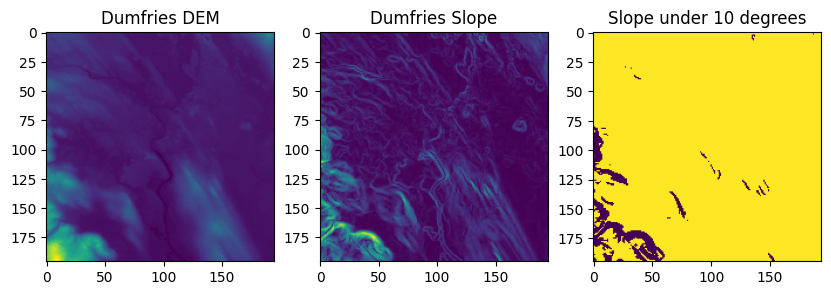

In [26]:
plt.rcParams["figure.figsize"] = [10, 8]

fig, ax = plt.subplots(1, 3)

ax[0].imshow(Dumfries_DEM.read(1), cmap="viridis")
ax[0].set_title("Dumfries DEM")

ax[1].imshow(Dumfries_Slope.read(1), cmap="viridis")
ax[1].set_title("Dumfries Slope")

ax[2].imshow(Gentle_Slope.read(1), cmap="viridis")
ax[2].set_title("Slope under 10 degrees")

plt.show()

## Results

**Suitability Distribution**

The weighted overlay produced a continuous suitability surface across 7,666.5 ha of land within the 5km study area surrounding Dumfries. Equal weights (0.333) were applied to the three continuous factors (distance to roads, distance to the River Nith, and distance to existing houses) following inconclusive comparison judgements.

Table 1 summarises the distribution of suitability scores when classified into three bands.
Table 1: Suitability classification summary
Band	Cells	Hectares	% of Study Area

Using a broader threshold of ≥0.5, 4,344.75 ha (56.7%) of the study area was classified as at least moderately suitable for residential development, while restricting this to the stricter ≥0.7 threshold narrowed the suitable area to 2,030.25 ha (26.5%).

**Spatial Pattern**

Figure 4 shows the classified suitability surface. Low suitability land forms a dense, branching pattern concentrated on the existing town of Dumfries, closely following the historic settlement pattern along the River Nith. This pattern reflects the combined effect of the built-up area exclusion and the flood extent exclusion, both of which are spatially coincident with the town centre and the immediate river corridor. High suitability land forms a broad ring of open land surrounding the town, corresponding to areas within reasonable proximity to the road network and existing houses, but lying outside the built-up footprint and the excluded flood and steep-slope zones.

Land scoring in the Very High band (≥0.8) was spatially concentrated in only two locations: a small area northwest of the town centre, and a substantially larger, contiguous block to the southeast. The concentration of Very High suitability into these two specific areas — despite over half the study area meeting the broader ≥0.5 threshold — indicates that land combining strong scores across all three factors while remaining clear of every constraint is considerably rarer and more spatially specific than a general suitability assessment alone would suggest.

**Answering the Research Question**

These results indicate that the areas around Dumfries most suitable for new residential development, once future flood risk from the River Nith, slope, and existing development are accounted for, are concentrated in a ring of land surrounding the existing urban area rather than within or immediately adjacent to it — most notably in a substantial block to the southeast of the town. This spatial separation between the historic town centre (predominantly low suitability, due to its riverside origins and existing development) and the identified suitable land reflects the extent to which flood risk and built-up land jointly constrain where new residential development can appropriately be directed.



In [11]:
elev = rio.open('/content/drive/MyDrive/GG3209_Research_Report/MCE_Clipped.tif')
print(elev.name)
print(elev.count)
print(elev.width)
print(elev.height)
print(elev.bounds)
print(elev.crs)
#elev.close()

/content/drive/MyDrive/GG3209_Research_Report/MCE_Clipped.tif
1
200
200
BoundingBox(left=292238.1415, bottom=571113.8967, right=302238.1415, top=581113.8967)
EPSG:27700


In [12]:
elev_arr = elev.read(1)
elev_arr

array([[-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       ...,
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.],
       [-9999., -9999., -9999., ..., -9999., -9999., -9999.]],
      dtype=float32)

In [13]:
image_read_masked = np.ma.masked_array(elev_arr, mask=(elev_arr == -9999))

## Figure 4 shows the final MCE output raster.

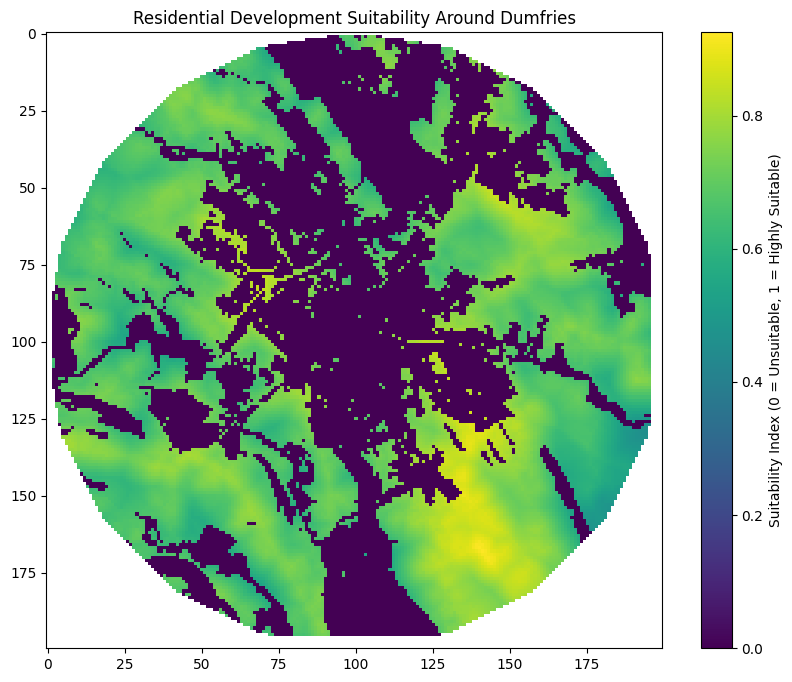

In [14]:
plt.rcParams['figure.figsize'] = [10, 8]
plt.imshow(image_read_masked, cmap="viridis")
plt.title("Residential Development Suitability Around Dumfries")
plt.colorbar(label="Suitability Index (0 = Unsuitable, 1 = Highly Suitable)")
plt.show()

In [27]:
suitable_cells = (image_read_masked >= 0.5).sum()

# If each cell is 50m x 50m = 2500 square metres = 0.25 hectares
cell_area_ha = 0.25

suitable_hectares = suitable_cells * cell_area_ha

print(f"Suitable cells: {suitable_cells}")
print(f"Suitable land: {suitable_hectares} hectares")

Suitable cells: 17379
Suitable land: 4344.75 hectares


In [28]:
total_cells = image_read_masked.count()
cell_area_ha = 0.25

total_hectares = total_cells * cell_area_ha

print(f"Total cells: {total_cells}")
print(f"Total land area: {total_hectares} hectares")

Total cells: 30666
Total land area: 7666.5 hectares


In [29]:
percent_suitable = 100 * suitable_cells / total_cells
print(f"{percent_suitable:.1f}% of the study area is suitable")

56.7% of the study area is suitable


In [30]:
table = pd.DataFrame({
    "Suitability": ["Low (<0.5)", "Medium (0.5-0.7)", "High (>=0.7)"],
    "Hectares": [low*cell_area_ha, medium*cell_area_ha, high*cell_area_ha],
    "% of Area": [100*low/total_cells, 100*medium/total_cells, 100*high/total_cells]
})
table

,Suitability,Hectares,% of Area
0,Low (<0.5),3321.75,43.328116
1,Medium (0.5-0.7),2314.50,30.189787
2,High (>=0.7),2030.25,26.482097


## Discussion

The overall pattern — low suitability concentrated on the town and river corridor, rising further from both the settlement core and flood extent — is consistent with comparable GIS flood suitability studies elsewhere (Halim, Jamru And Jafar, 2026). The Very High suitability block identified southeast of Dumfries, clear of both flood extent and development, reflects this literature's broader finding that flood-informed MCE redirects suitable development away from historic riverside cores toward peripheral higher ground, directly relevant to NPF4 Policy 22's flood avoidance principle (Scottish Government, 2025).

Several limitations should be acknowledged. The comparison did not yield different weights, resulting in equal weighting (0.333) across all three continuous factors — a simplification driven by the absence of a clear basis for prioritising one factor over another without domain expertise in local planning priorities, rather than genuine expert judgement. A structured, stakeholder-informed process with an accompanying sensitivity analysis would produce more defensible weights and clarify how strongly the results depend on this choice.

The study also used only the future flood extent as a constraint, rather than directly comparing present-day and future scenarios; a difference-map approach would more explicitly isolate flood risk's marginal effect. Similarly, only the medium-likelihood scenario was tested, despite NPF4 Policy 22's concern with worst-case as well as typical exposure — testing the more precautionary low-likelihood extent would be a valuable robustness check and might further reduce the suitable area identified, particularly at flood-adjacent margins. The 50m resolution and 5km study area radius, while reasonable given project constraints, were not tested for sensitivity, and SEPA's available depth/velocity and multi-likelihood data were not used. This study also did not factor in other forms of flooding – instead it focused purely on river flooding. I’d recommend combining or researching the different flooding types in another project.

Finally, the model does not account for existing land use beyond built-up areas — agricultural land, nature reserves, and saltmarsh habitat were not distinguished from generally open land.
Future work could address these limitations through a full present-versus-future comparative MCE, stakeholder-informed weighting with sensitivity analysis, multiple flood likelihood scenarios, additional land-use constraints, and validation against historical planning decisions.



## Conclusion

This study set out to answer the research question: which areas around Dumfries are most suitable for new residential development when accounting for projected future flood risk from the River Nith? Using a GIS-based Multi-Criteria Evaluation combining distance to roads, distance to the River Nith, and distance to existing houses as weighted factors, with future flood extent, existing built-up areas, and steep slope applied as hard constraints, this study found that 56.7% of the 7,666.5 ha study area meets a moderate suitability threshold, narrowing to 26.5% under a stricter high-suitability threshold. Suitable land was found to be spatially concentrated in a ring surrounding the existing town rather than within it, with a particularly notable block of very high suitability land identified to the southeast of Dumfries, clear of both the mapped future flood extent and existing development.
These findings suggest that accounting for future, climate-change-adjusted flood risk meaningfully constrains where new residential development can appropriately be directed around Dumfries, reinforcing the principle embedded in National Planning Framework 4 Policy 22 that flood-prone land should be avoided in development allocation. The identification of specific, spatially concentrated areas of high suitability — rather than a diffuse pattern across the study area — indicates that flood-informed suitability modelling can meaningfully narrow the search space for future residential site allocation, even using a relatively simple, transparent MCE structure.
The main contribution of this project is a reproducible, open-data-based MCE workflow, combining QGIS spatial preprocessing with Python-based weighting and overlay computation, that could be readily extended or re-applied to other Scottish towns facing similar riverine flood risk. Future work incorporating differentiated stakeholder-informed criteria weights, a direct present-versus-future flood risk comparison, and broader land-use constraints would build meaningfully on the findings presented here.



## References

•	Author (2018). QGIS in Action: Mapping Flood Risk and Emergency Response · QGIS India User Group. [online] Qgis.org. Available at: https://in.qgis.org/case-studies/kerala-flood-risk-mapping/ [Accessed 21 Sept. 2026].

•	Chen, K., Blong, R. and Jacobson, C. (2001). MCE-RISK: integrating multicriteria evaluation and GIS for risk decision-making in natural hazards. Environmental Modelling & Software, 16(4), pp.387–397. doi:10.1016/s1364-8152(01)00006-8.

•	Flooding in communities Moving towards flood resilience. (n.d.). [online] Available at: https://audit.scot/uploads/2025-08/
nr_250828_flooding_in_communities.pdf [Accessed 21 Sept. 2026].
•	Hakimian, R. (2025). Dumfries councillors approve £68.6M flood defence, allowing work to begin spring 2026 | New Civil Engineer. [online] New Civil Engineer. Available at: https://www.newcivilengineer.com/latest/dumfries-councillors-approve-68-6m-flood-defence-allowing-work-to-begin-spring-2026-11-12-2025/ [Accessed 21 Sept. 2026].

•	HALIM, M.F.H.A., JAMRU, L.R. and JAFAR, A. (2026). FLOOD RISK DETERMINANTS IN GIS-BASED STUDIES: A SYSTEMATIC REVIEW USING AHP AND MCDA. Quantum Journal of Social Sciences and Humanities, [online] 7(2), pp.405–419. doi:10.55197/qjssh.v7i2.1127.

•	Montgomery Homes (2021). Very Steep Slope House Plans: How Steep Is Too Steep? [online] Montgomery Homes. Available at: https://www.montgomeryhomes.com.au/blog/how-steep-is-too-steep/ [Accessed 21 Sept. 2026].

•	Scottish Government (2023). National Planning Framework 4. [online] Available at: https://www.gov.scot/binaries/content/documents/govscot/publications/strategy-plan/2023/02/national-planning-framework-4/documents/national-planning-framework-4-revised-draft/national-planning-framework-4-revised-draft/govscot%3Adocument/national-planning-framework-4.pdf [Accessed 21 Sept. 2026].

•	The Dumfries street that has flooded more than 200 times. (2023). BBC News. [online] 2 Oct. Available at: https://www.bbc.co.uk/news/uk-scotland-south-scotland-66867199 [Accessed 21 Sept. 2026].

•	UK Centre for Ecology & Hydrology. (n.d.). UK Centre for Ecology & Hydrology. [online] Available at: https://www.ceh.ac.uk/ [Accessed 21 Sept. 2026].
